In [4]:
# ==========================================
# PCA + DBSCAN + Separate cluster plots
# ==========================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. Load data
# -----------------------------
real = pd.read_csv(r"D:/KLAUS/Vis_Final_Project/real_feature_output/real_features.csv").copy()
fake = pd.read_csv(r"D:/KLAUS/Vis_Final_Project/fake_feature_output/fake_features.csv").copy()

real["type"] = "real"
fake["type"] = "fake"

df = pd.concat([real, fake], ignore_index=True).copy()

# -----------------------------
# 2. Feature columns
# -----------------------------
feature_cols = [c for c in df.columns if re.fullmatch(r"f\d{3}", c)]

# Standardize BEFORE PCA (important for DBSCAN)
scaler = StandardScaler()
X = scaler.fit_transform(df[feature_cols])

y = df["type"].values

# -----------------------------
# 3. PCA
# -----------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# -----------------------------
# 4. DBSCAN
# -----------------------------
# 🔥 Tune these parameters
dbscan = DBSCAN(eps=0.15, min_samples=10)
clusters = dbscan.fit_predict(X_pca)

# -----------------------------
# 5. Build dataframe
# -----------------------------
df_cluster = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "type": y,
    "cluster": clusters
})

# # -----------------------------
# # 6. Global plot
# # -----------------------------
# plt.figure(figsize=(9,7))

# for label, color in zip(["real", "fake"], ["blue", "orange"]):
#     subset = df_cluster[df_cluster["type"] == label]
#     plt.scatter(subset["PC1"], subset["PC2"], c=color, alpha=0.5, label=label)

# plt.title("PCA with DBSCAN Clustering")
# plt.xlabel("PC1")
# plt.ylabel("PC2")
# plt.legend()
# plt.show()

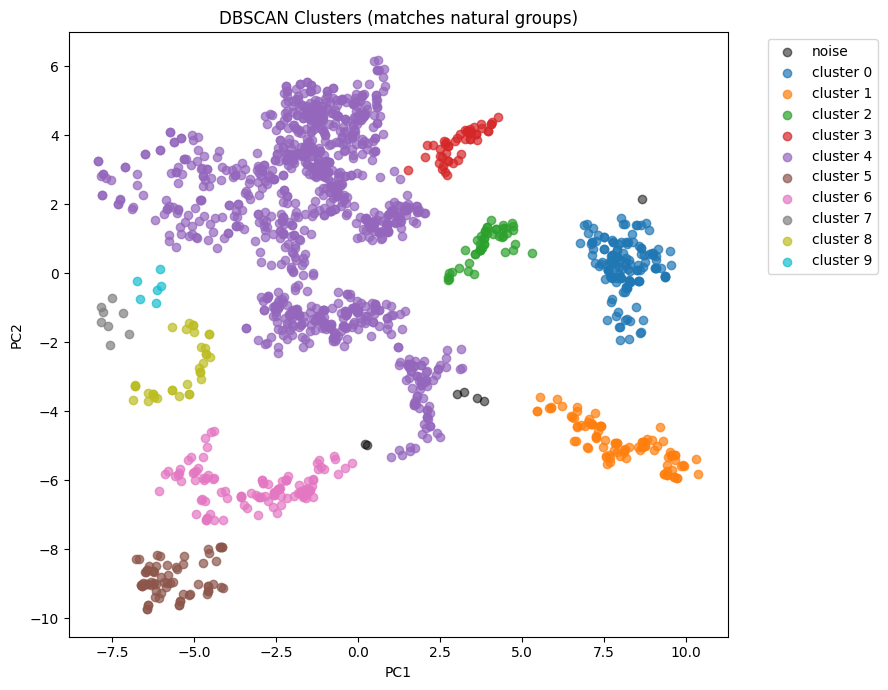

In [5]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.65, min_samples=5)  # tune eps!
clusters = dbscan.fit_predict(X_pca)


plt.figure(figsize=(9,7))

unique_clusters = np.unique(clusters)

for c in unique_clusters:
    subset = X_pca[clusters == c]
    
    if c == -1:
        plt.scatter(subset[:,0], subset[:,1], c='black', label='noise', alpha=0.5)
    else:
        plt.scatter(subset[:,0], subset[:,1], label=f'cluster {c}', alpha=0.7)

plt.title("DBSCAN Clusters (matches natural groups)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

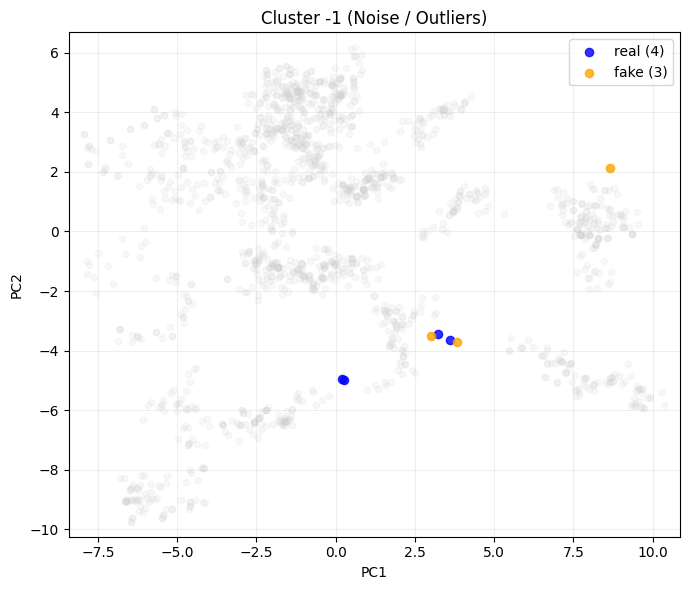


Cluster -1 composition:
type
real    4
fake    3
Name: count, dtype: int64


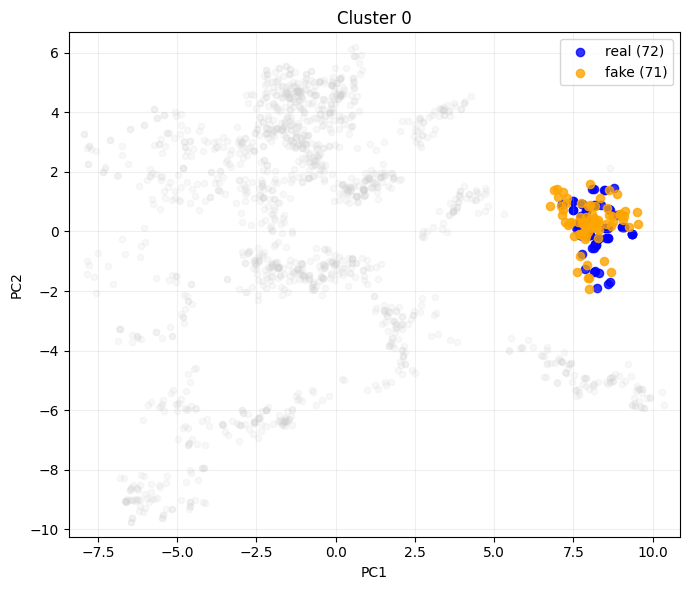


Cluster 0 composition:
type
real    72
fake    71
Name: count, dtype: int64


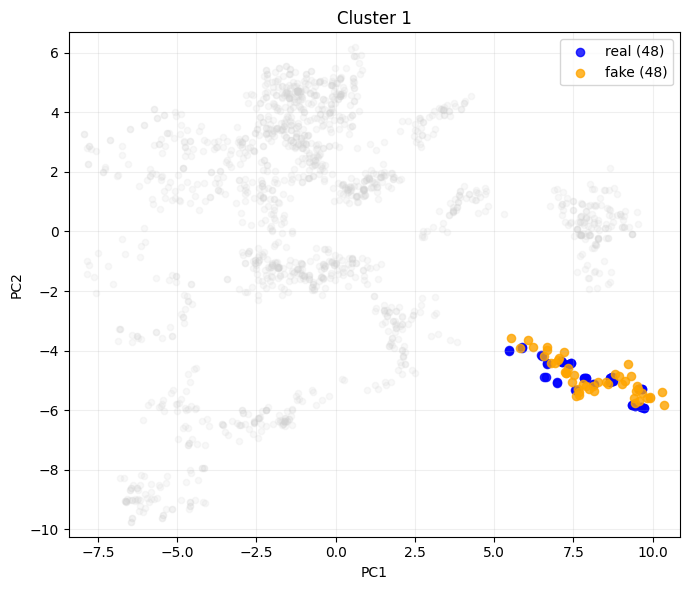


Cluster 1 composition:
type
real    48
fake    48
Name: count, dtype: int64


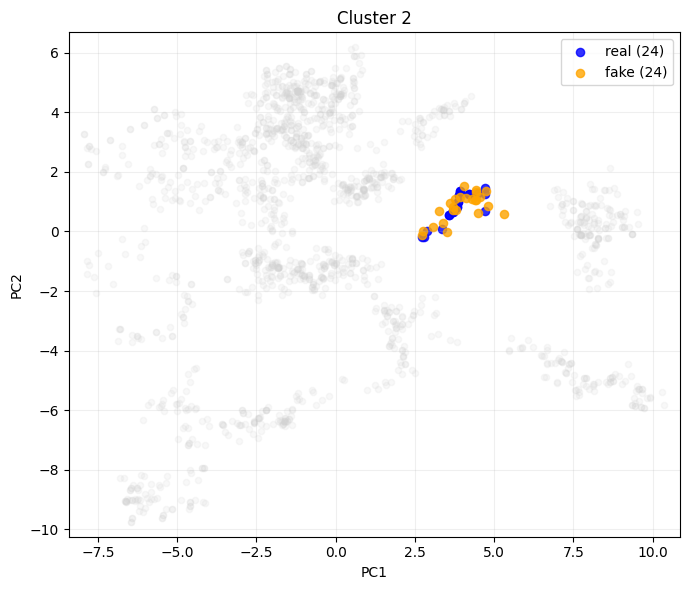


Cluster 2 composition:
type
real    24
fake    24
Name: count, dtype: int64


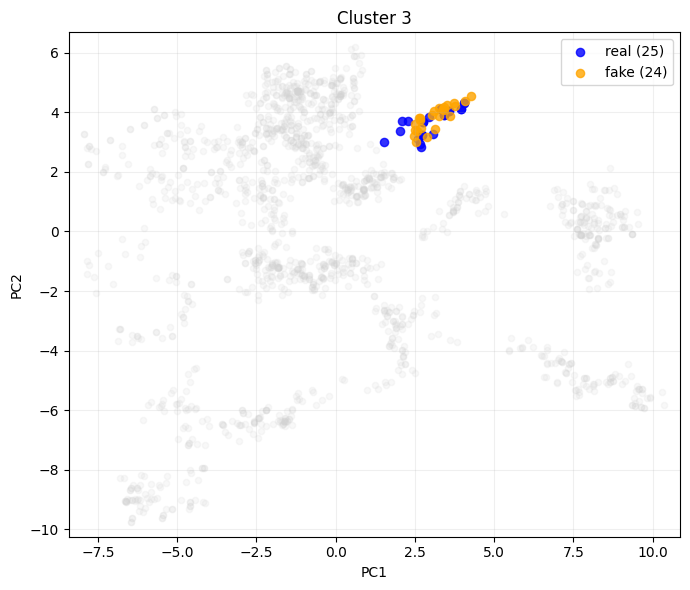


Cluster 3 composition:
type
real    25
fake    24
Name: count, dtype: int64


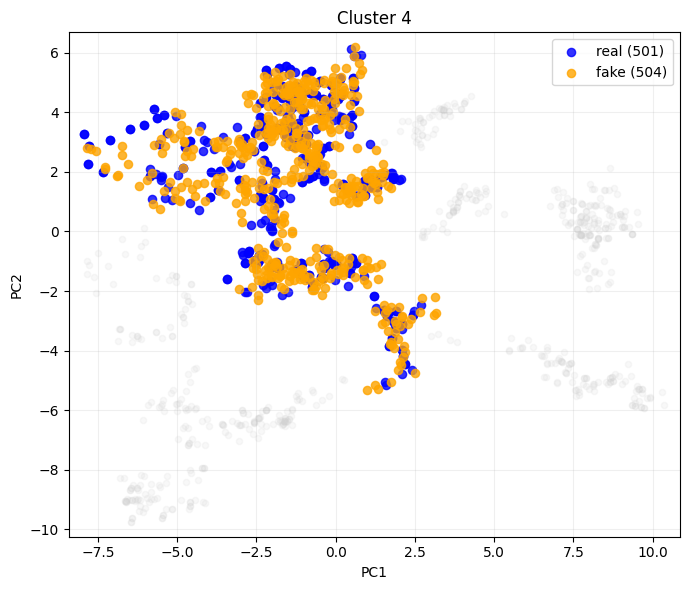


Cluster 4 composition:
type
fake    504
real    501
Name: count, dtype: int64


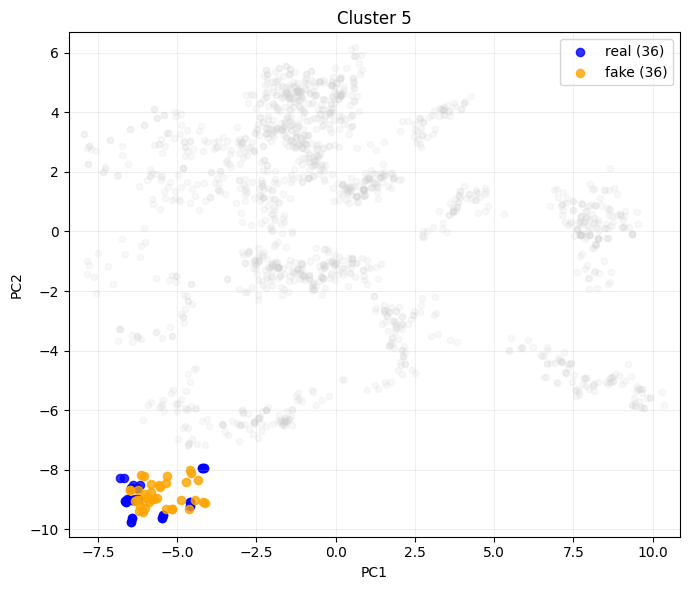


Cluster 5 composition:
type
real    36
fake    36
Name: count, dtype: int64


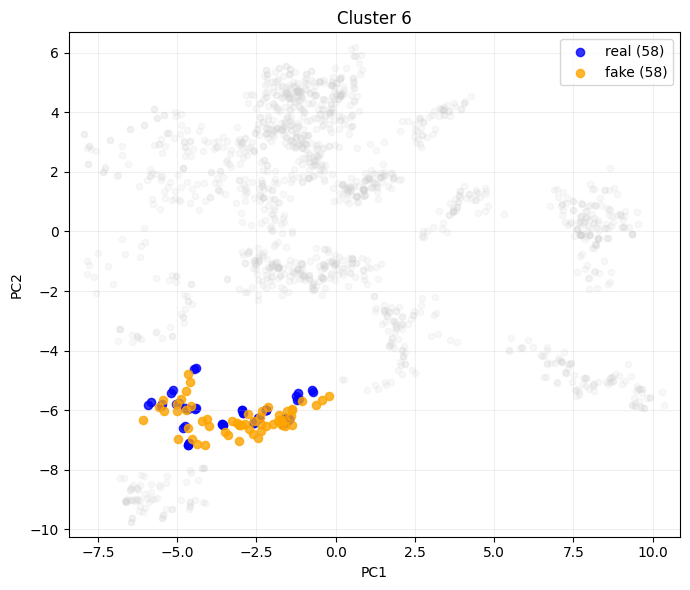


Cluster 6 composition:
type
real    58
fake    58
Name: count, dtype: int64


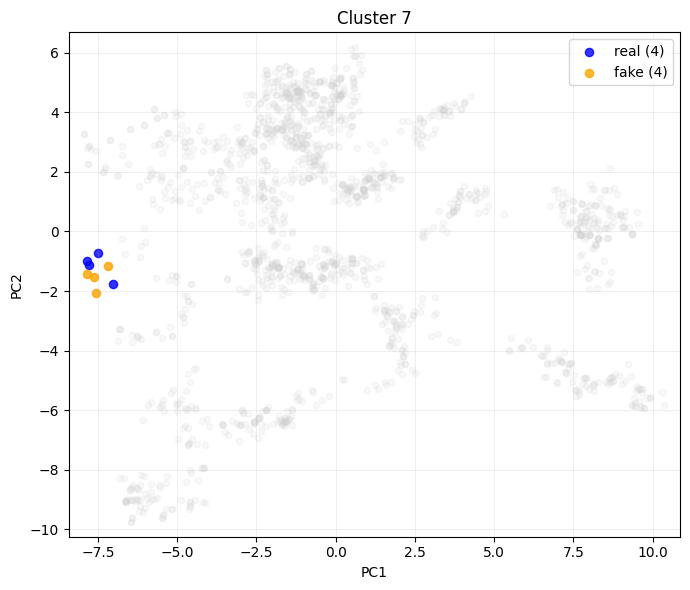


Cluster 7 composition:
type
real    4
fake    4
Name: count, dtype: int64


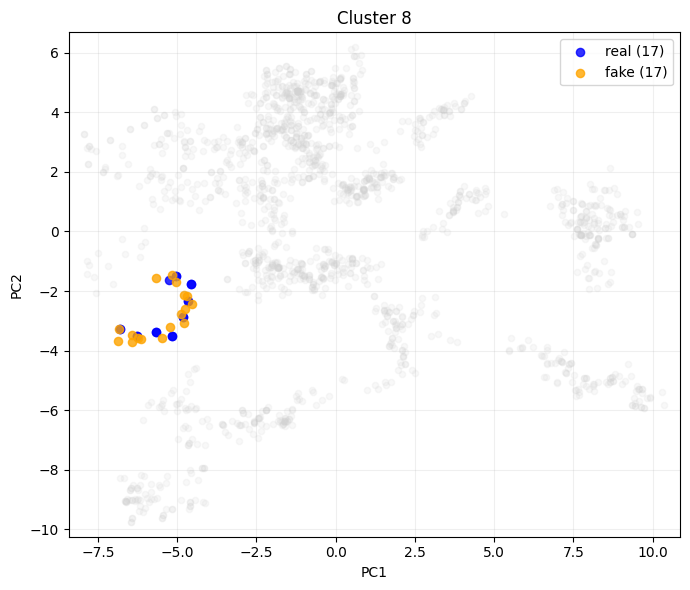


Cluster 8 composition:
type
real    17
fake    17
Name: count, dtype: int64


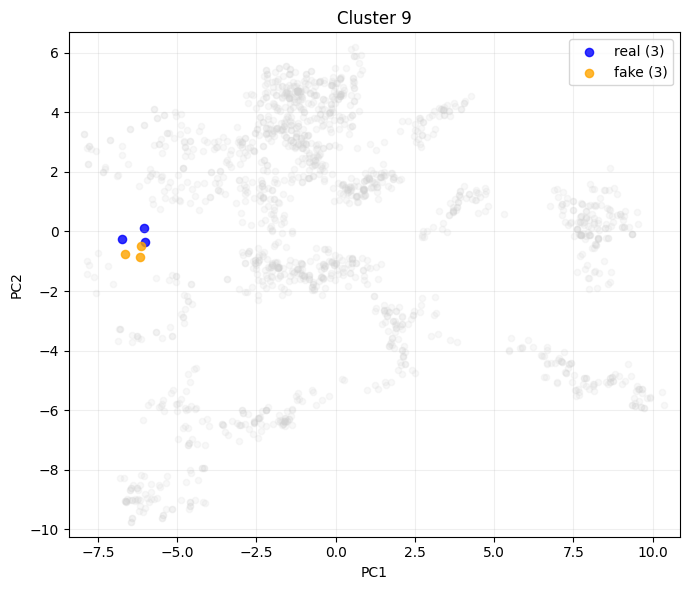


Cluster 9 composition:
type
real    3
fake    3
Name: count, dtype: int64


In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Dataframe with PCA coordinates + labels + clusters
df_cluster = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "type": y,
    "cluster": clusters
})

unique_clusters = sorted(df_cluster["cluster"].unique())

# Global axis limits from full PCA plot
x_min, x_max = X_pca[:, 0].min(), X_pca[:, 0].max()
y_min, y_max = X_pca[:, 1].min(), X_pca[:, 1].max()

for c in unique_clusters:
    subset = df_cluster[df_cluster["cluster"] == c]

    plt.figure(figsize=(7, 6))

    # optional: show all points faintly in background
    plt.scatter(
        df_cluster["PC1"], df_cluster["PC2"],
        c="lightgray", alpha=0.15, s=20
    )

    # real and fake points of only this cluster
    real_points = subset[subset["type"] == "real"]
    fake_points = subset[subset["type"] == "fake"]

    plt.scatter(
        real_points["PC1"], real_points["PC2"],
        c="blue", alpha=0.8, s=35, label=f"real ({len(real_points)})"
    )
    plt.scatter(
        fake_points["PC1"], fake_points["PC2"],
        c="orange", alpha=0.8, s=35, label=f"fake ({len(fake_points)})"
    )

    # keep SAME positioning as full plot
    plt.xlim(x_min - 0.5, x_max + 0.5)
    plt.ylim(y_min - 0.5, y_max + 0.5)

    if c == -1:
        plt.title("Cluster -1 (Noise / Outliers)")
    else:
        plt.title(f"Cluster {c}")

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    print(f"\nCluster {c} composition:")
    print(subset["type"].value_counts())

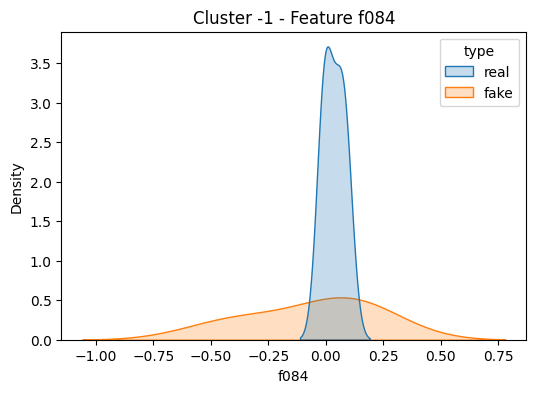

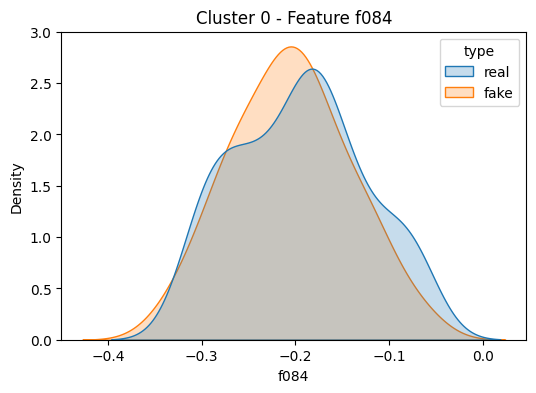

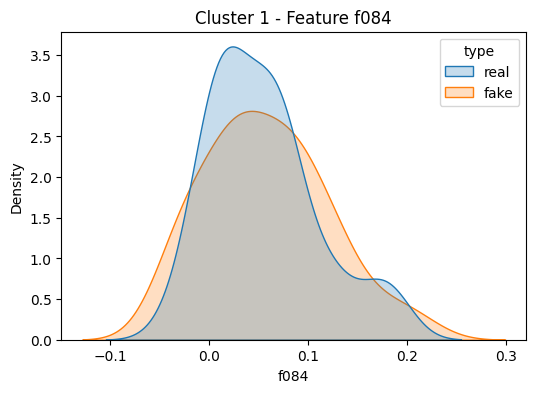

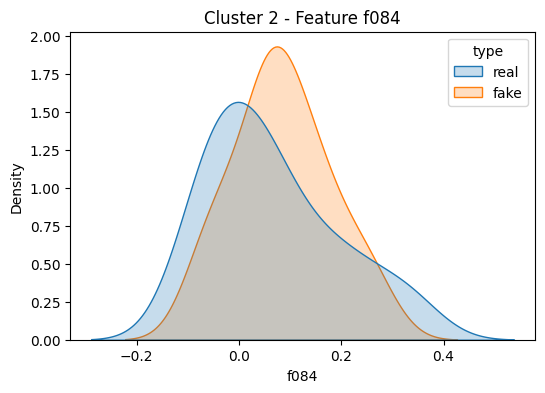

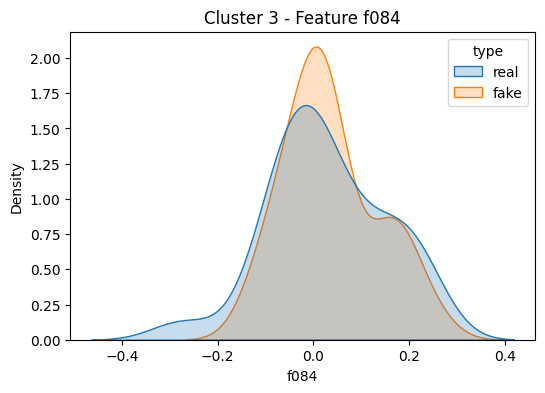

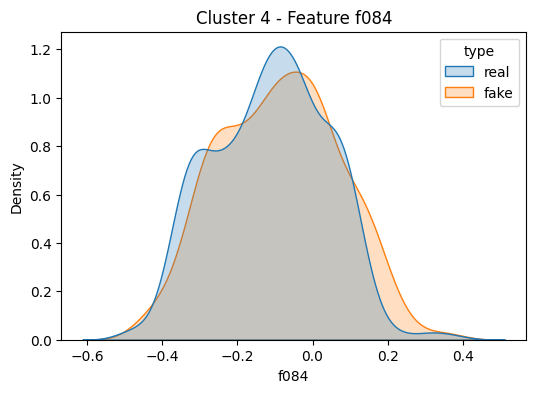

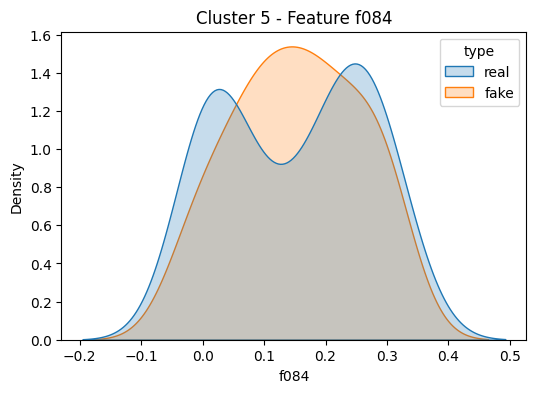

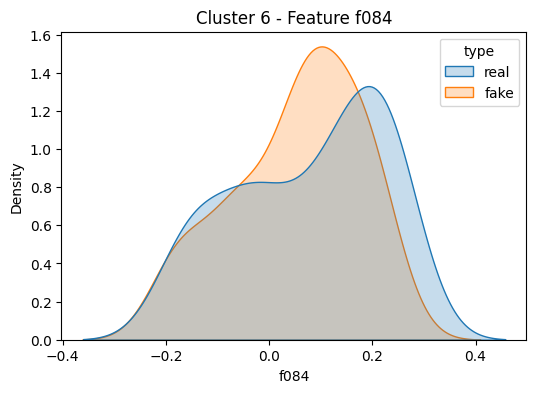

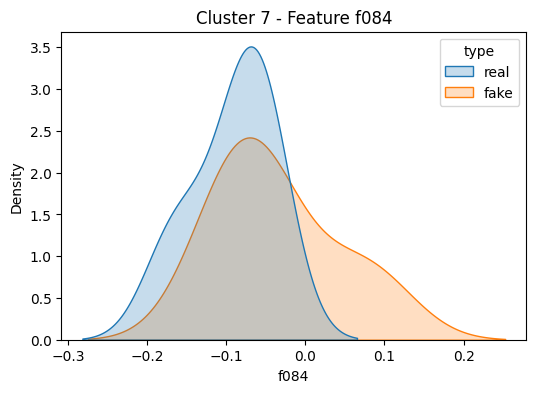

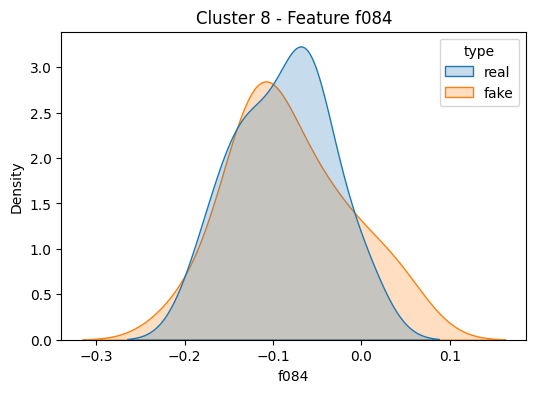

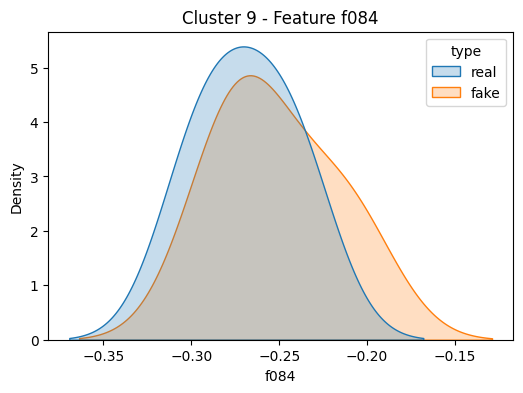

In [7]:
import seaborn as sns

for c in sorted(df_cluster["cluster"].unique()):
    subset = df_cluster["cluster"] == c
    
    plt.figure(figsize=(6,4))
    sns.kdeplot(
        data=df.loc[subset],
        x="f084",   # your feature
        hue=df.loc[subset, "type"],
        fill=True
    )
    plt.title(f"Cluster {c} - Feature f084")
    plt.show()

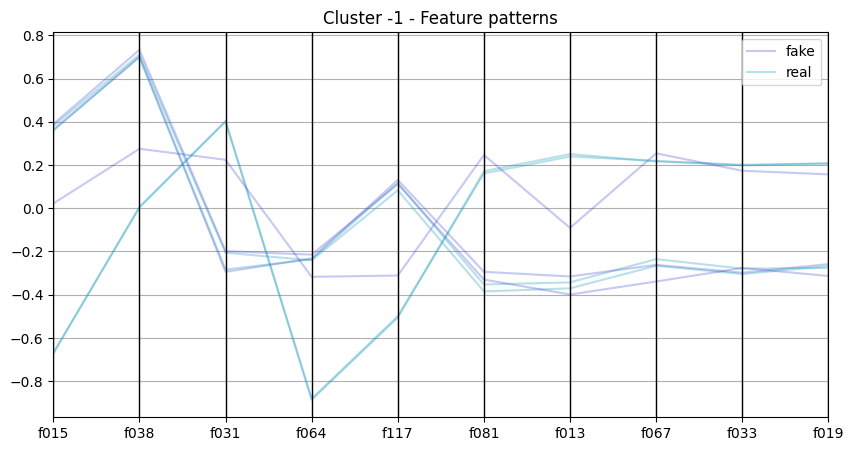

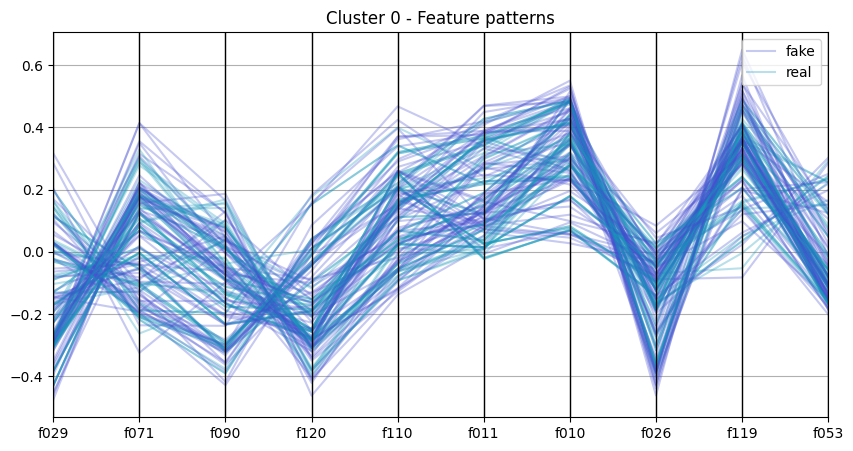

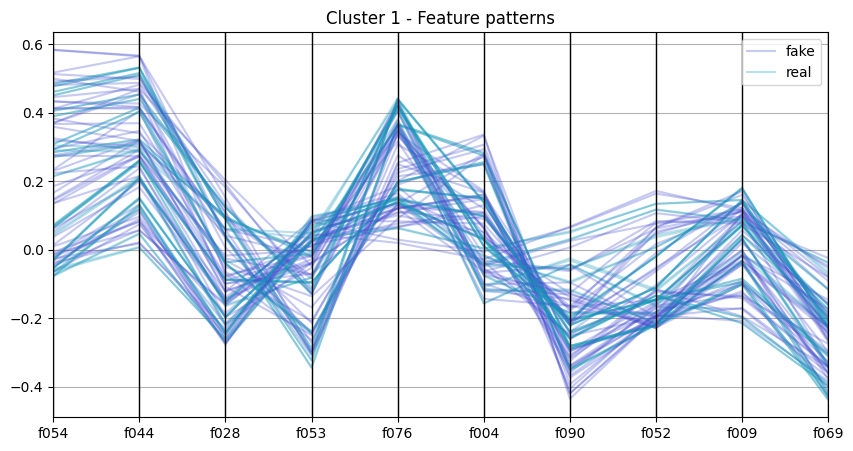

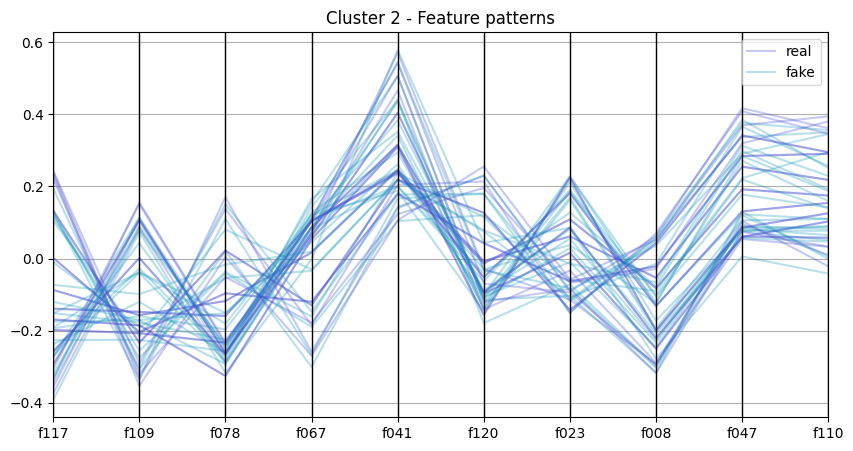

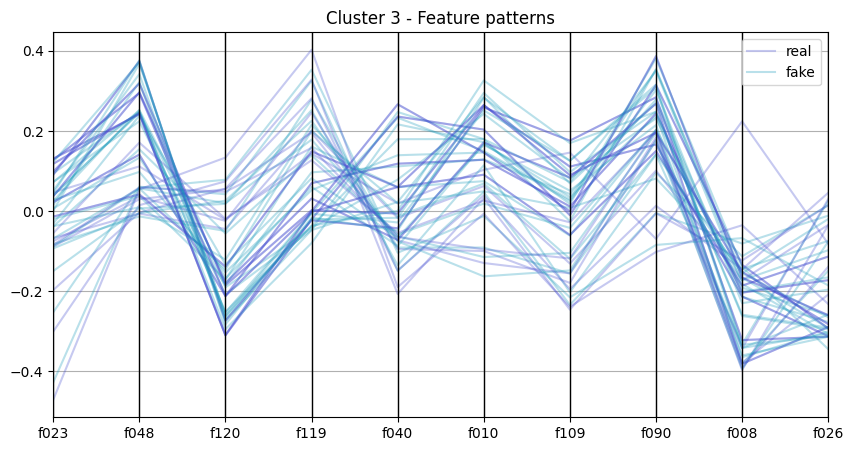

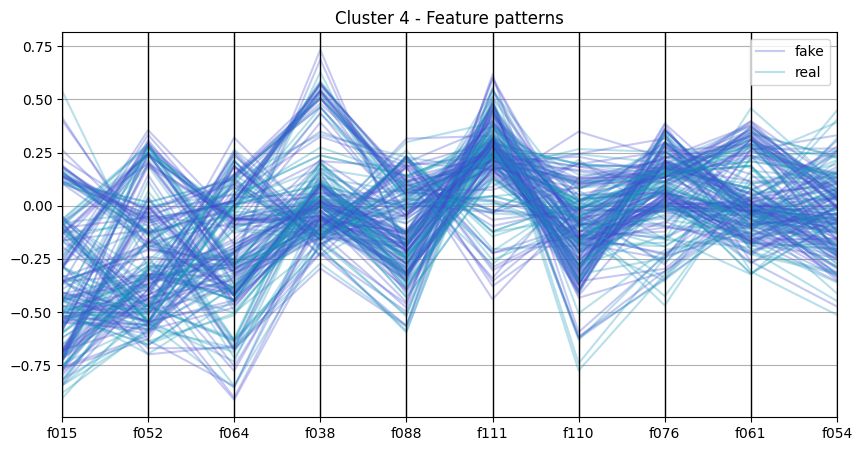

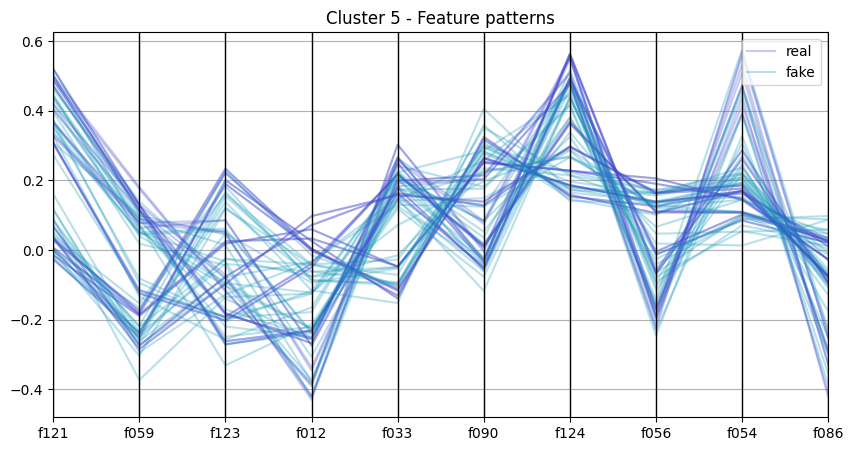

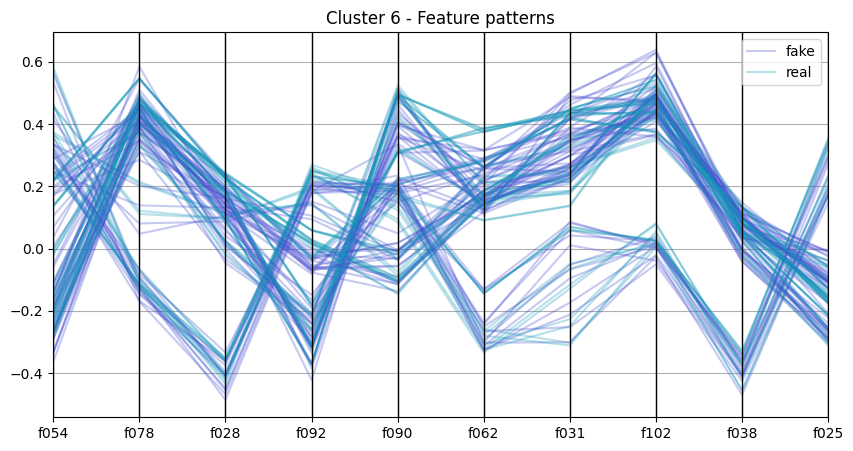

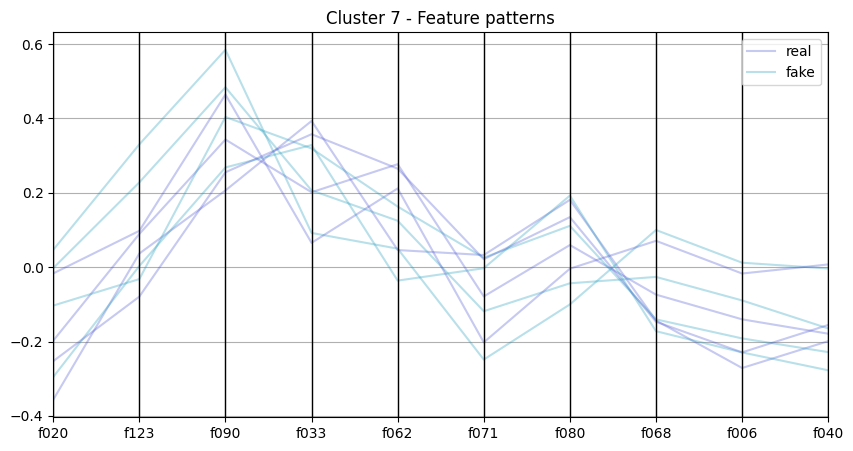

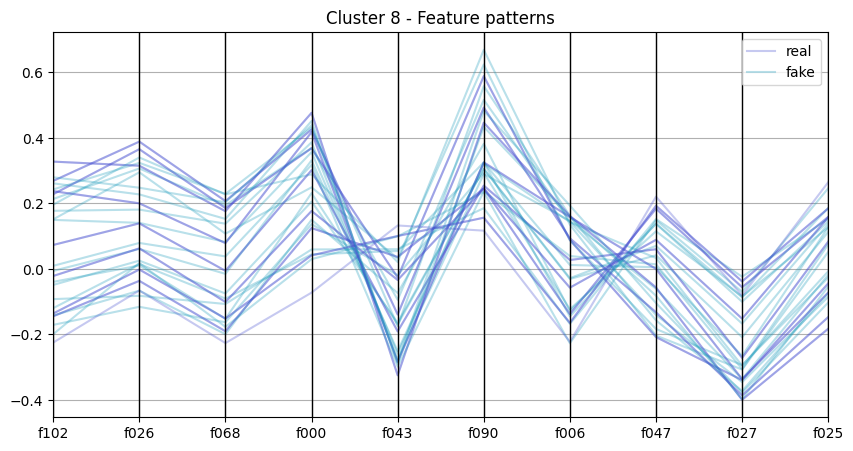

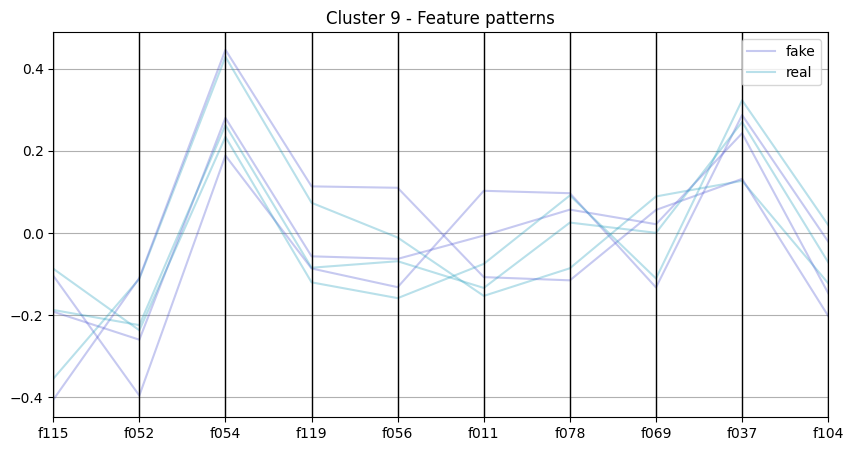

In [8]:
from pandas.plotting import parallel_coordinates

for c in sorted(df_cluster["cluster"].unique()):
    subset = df_cluster["cluster"] == c
    
    temp = df.loc[subset, feature_cols].copy()
    temp["type"] = df.loc[subset, "type"]

    top_features = temp.drop("type", axis=1).var().sort_values(ascending=False).head(10).index
    temp = temp[list(top_features) + ["type"]]

    plt.figure(figsize=(10,5))
    parallel_coordinates(temp.sample(min(200, len(temp))), "type", alpha=0.3)
    plt.title(f"Cluster {c} - Feature patterns")
    plt.show()

In [9]:
from sklearn.neighbors import NearestNeighbors

for c in sorted(df_cluster["cluster"].unique()):
    subset_idx = df_cluster["cluster"] == c
    subset_features = X[subset_idx]

    nbrs = NearestNeighbors(n_neighbors=5).fit(subset_features)
    distances, _ = nbrs.kneighbors(subset_features)

    print(f"\nCluster {c} avg NN distance:", distances.mean())


Cluster -1 avg NN distance: 8.400063285739346

Cluster 0 avg NN distance: 2.14889064053336

Cluster 1 avg NN distance: 1.7386518674728029

Cluster 2 avg NN distance: 2.2784934677624267

Cluster 3 avg NN distance: 2.3926489284223322

Cluster 4 avg NN distance: 2.0451439949067183

Cluster 5 avg NN distance: 1.7710250167438606

Cluster 6 avg NN distance: 1.9531849084273263

Cluster 7 avg NN distance: 4.017021932236403

Cluster 8 avg NN distance: 2.5725339486918823

Cluster 9 avg NN distance: 3.946977154764589


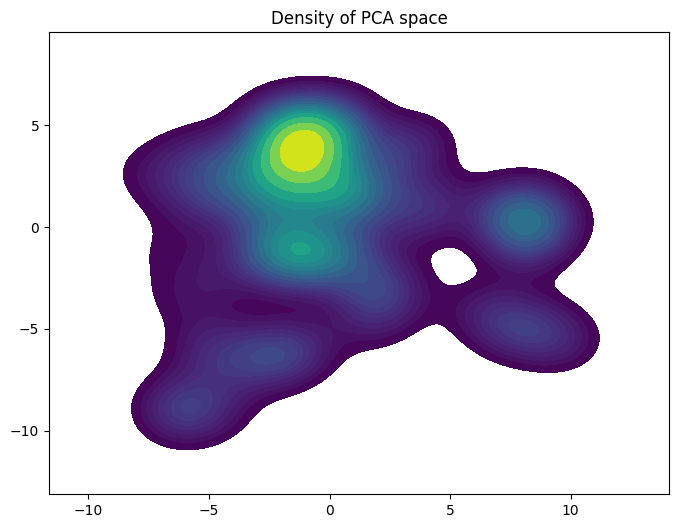

In [10]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.kdeplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    fill=True,
    cmap="viridis",
    levels=20
)
plt.title("Density of PCA space")
plt.show()

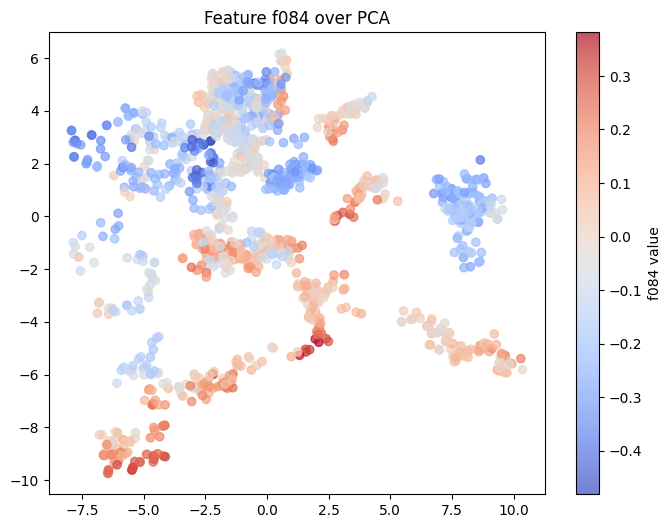

In [11]:
plt.figure(figsize=(8,6))

sc = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df["f084"],   # 🔥 feature coloring
    cmap="coolwarm",
    alpha=0.7
)

plt.colorbar(sc, label="f084 value")
plt.title("Feature f084 over PCA")
plt.show()

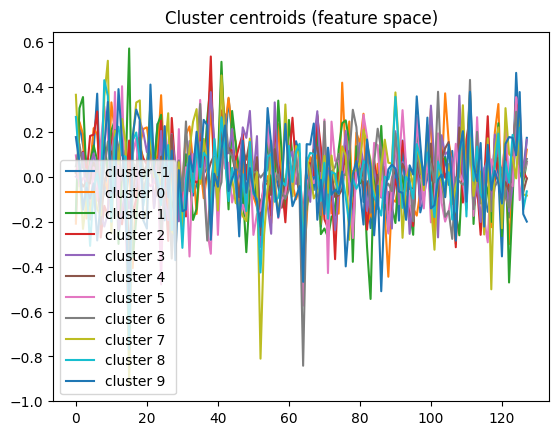

In [12]:
for c in sorted(df_cluster["cluster"].unique()):
    subset_idx = df_cluster["cluster"] == c
    centroid = df.loc[subset_idx, feature_cols].mean()

    plt.plot(centroid.values, label=f'cluster {c}')

plt.legend()
plt.title("Cluster centroids (feature space)")
plt.show()

In [13]:
cluster_id = 4

idx = df_cluster["cluster"] == cluster_id

X_c = X[idx]                      # standardized features
df_c = df.loc[idx].copy()         # original features
labels_c = df_c["type"]

In [14]:
# Compare cluster vs global
global_mean = df[feature_cols].mean()
cluster_mean = df_c[feature_cols].mean()

importance = (cluster_mean - global_mean).abs().sort_values(ascending=False)

print("Top defining features:")
print(importance.head(15))

Top defining features:
f027    0.101747
f048    0.082290
f075    0.072743
f064    0.071183
f102    0.065936
f023    0.065303
f108    0.064465
f007    0.062789
f015    0.062524
f069    0.062185
f002    0.059801
f001    0.057638
f081    0.057290
f110    0.057154
f051    0.054380
dtype: float64


In [15]:
real_mean = df_c[df_c["type"]=="real"][feature_cols].mean()
fake_mean = df_c[df_c["type"]=="fake"][feature_cols].mean()

diff = (fake_mean - real_mean).sort_values(key=np.abs, ascending=False)

print("Top real vs fake differences:")
print(diff.head(10))

Top real vs fake differences:
f084    0.023366
f108   -0.020955
f052   -0.018310
f008    0.017570
f013    0.017280
f081    0.016582
f044   -0.015925
f105   -0.015737
f046   -0.015287
f009   -0.015127
dtype: float64


In [16]:
from scipy.stats import ttest_ind

real_vals = df_c[df_c["type"]=="real"][feature_cols]
fake_vals = df_c[df_c["type"]=="fake"][feature_cols]

p_values = []

for f in feature_cols:
    _, p = ttest_ind(real_vals[f], fake_vals[f], equal_var=False)
    p_values.append(p)

p_df = pd.Series(p_values, index=feature_cols).sort_values()

print("Statistically different features:")
print(p_df.head(10))

Statistically different features:
f044    0.006333
f084    0.018187
f030    0.030706
f008    0.036277
f108    0.043746
f122    0.063580
f105    0.064209
f033    0.081734
f081    0.086036
f009    0.106159
dtype: float64


In [17]:
cluster_var = df_c[feature_cols].var().sort_values(ascending=False)

print("Most varying features:")
print(cluster_var.head(10))

Most varying features:
f015    0.109174
f052    0.080956
f064    0.079743
f038    0.054114
f088    0.040775
f111    0.039396
f110    0.037168
f076    0.034650
f061    0.034103
f054    0.033886
dtype: float64


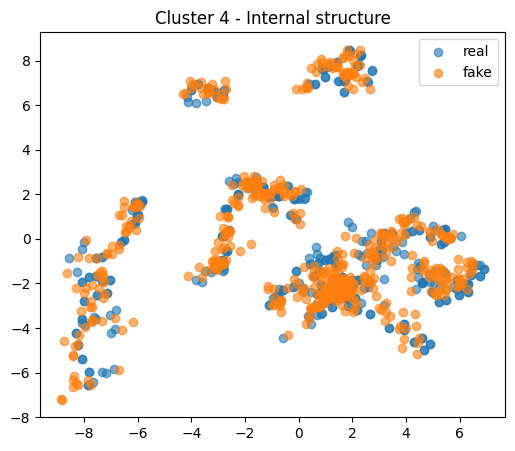

In [18]:
pca_local = PCA(n_components=2)
X_local = pca_local.fit_transform(X_c)

plt.figure(figsize=(6,5))
for t, color in zip(["real","fake"], ["blue","orange"]):
    sub = X_local[labels_c == t]
    plt.scatter(sub[:,0], sub[:,1], alpha=0.6, label=t)

plt.title("Cluster 4 - Internal structure")
plt.legend()
plt.show()

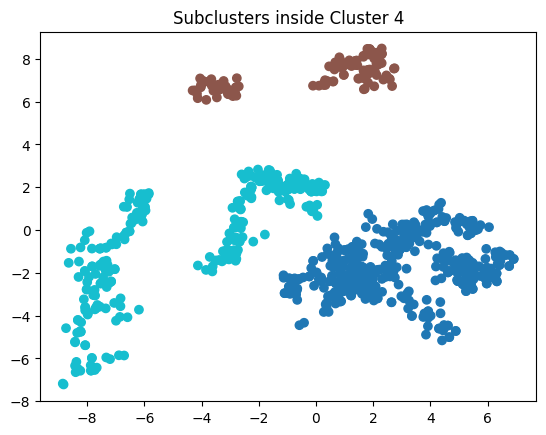

In [32]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
subclusters = kmeans.fit_predict(X_c)

plt.scatter(X_local[:,0], X_local[:,1], c=subclusters, cmap='tab10')
plt.title("Subclusters inside Cluster 4")
plt.show()

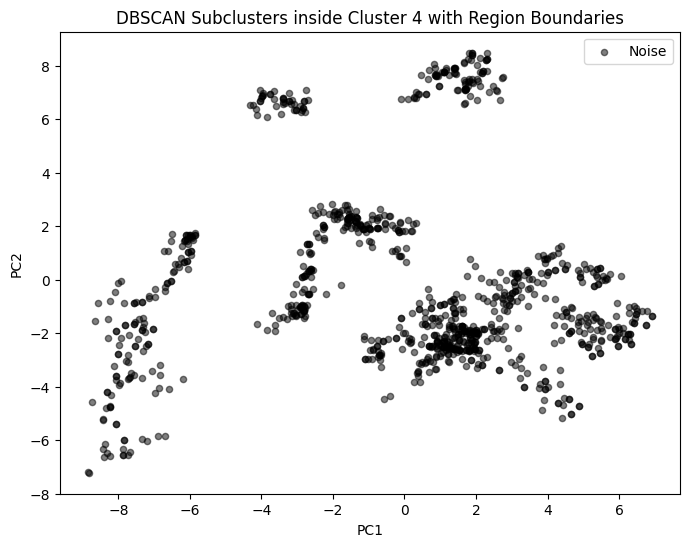

In [33]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from scipy.spatial import ConvexHull

# -----------------------------------
# 1. Scale data for DBSCAN
# -----------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_c)   # use X_c for clustering

# -----------------------------------
# 2. DBSCAN
# -----------------------------------
dbscan = DBSCAN(eps=0.35, min_samples=8)   # tune these
subclusters = dbscan.fit_predict(X_scaled)

# -----------------------------------
# 3. Plot points + region boundary
# -----------------------------------
plt.figure(figsize=(8, 6))

unique_labels = np.unique(subclusters)

for label in unique_labels:
    cluster_mask = (subclusters == label)
    pts = X_local[cluster_mask]   # plot in local PCA space

    if label == -1:
        # noise points
        plt.scatter(
            pts[:, 0], pts[:, 1],
            c='black', s=20, alpha=0.5, label='Noise'
        )
    else:
        plt.scatter(
            pts[:, 0], pts[:, 1],
            s=25, alpha=0.8, label=f'Cluster {label}'
        )

        # draw convex hull only if enough points
        if len(pts) >= 3:
            hull = ConvexHull(pts)
            hull_pts = pts[hull.vertices]

            # close the polygon
            hull_pts = np.vstack([hull_pts, hull_pts[0]])

            plt.fill(
                hull_pts[:, 0], hull_pts[:, 1],
                alpha=0.2
            )
            plt.plot(
                hull_pts[:, 0], hull_pts[:, 1],
                linewidth=2
            )

plt.title("DBSCAN Subclusters inside Cluster 4 with Region Boundaries")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

In [22]:
from sklearn.metrics import pairwise_distances

real_X = X_c[labels_c == "real"]
fake_X = X_c[labels_c == "fake"]

dist_real_real = pairwise_distances(real_X).mean()
dist_fake_fake = pairwise_distances(fake_X).mean()
dist_real_fake = pairwise_distances(real_X, fake_X).mean()

print("RR:", dist_real_real)
print("FF:", dist_fake_fake)
print("RF:", dist_real_fake)

RR: 14.62683568565573
FF: 14.382813809446288
RF: 14.537193134327792


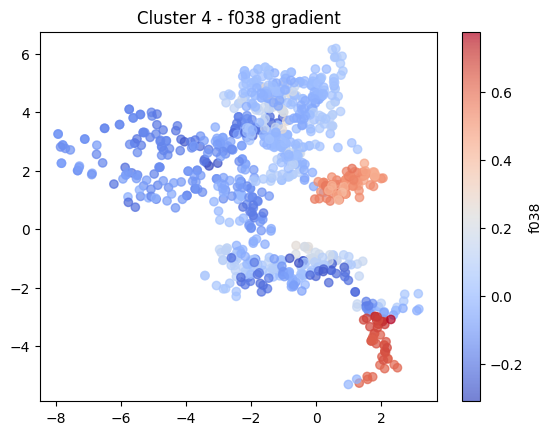

In [23]:
feature = "f038"   # pick top feature

plt.scatter(
    X_pca[idx,0],
    X_pca[idx,1],
    c=df_c[feature],
    cmap="coolwarm",
    alpha=0.7
)
plt.colorbar(label=feature)
plt.title(f"Cluster 4 - {feature} gradient")
plt.show()